# Objectif 

L'objectif de ce notebook est d'illustrer les différents estimateurs du vecteur de RTF en terme : 

* De justesse (biais) 
* De fidélité (écart type de l'erreur)
* De temps de calcul 

Les méthodes Cs, CW, CS-EVD testée repose sur l'hypothèse de stationnarité au sens large des signaux considérés afin d'estimer les composantes fréquentielles du vecteur de RTF bin fréquentiel par bin fréquentiel (Bologni et al. 2025, Napolitano 2020). Afin de tester cette hypothèse plusieurs signaux sources sont considérés : 

* Bruit blanc : stationnaire au sens large 
* Bruit rose : légèrement non stationnaire 
* Chirp LFM : fortement non stationnaire 

En particulier, on s'intéresse à la propagation dans un canal de propagation dons les paramètres sont ajustés pour réduire la durée de la réponse impulsionnelle et ainsi réduire la taille des fenêtres utilisées pour le calcul des matrices de covariances et donc pour le calcul du vecteur de RTF. 

L'environnement considéré est un guide d'onde de Pekeris dont les paramètres sont les suivants : 

* Dans la colonne d'eau :
    * $c_0 = 1500 m/s$
    * $\rho_0 = 1000 kg/m^3$
* Dans le sédiment : 
    * $c_1 = 1600 m/s$
    * $\rho_1 = 1500 kg/m^3$
    * $\alpha_1 = 0.2 dB/\lambda$

Références : 
* Bologni, G., Hendriks, R. C., & Heusdens, R. (2025). Wideband Relative Transfer Function (RTF) Estimation Exploiting Frequency Correlations. IEEE Transactions on Audio, Speech and Language Processing, 33, 731–747. https://doi.org/10.1109/TASLPRO.2025.3533371
* Napolitano, A. (2020). A - Nonstationary signal analysis. In A. Napolitano (Ed.), Cyclostationary Processes and Time Series (pp. 471–478). Academic Press. https://doi.org/https://doi.org/10.1016/B978-0-08-102708-0.00028-5


In [1]:
import os
import sys
import numpy as np
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# Load usefull functions
from signals.AcousticComponent import AcousticSource
from source.signal_generator import SignalGenerator
from source.rtf_estimator import RTFEstimator

import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure
from misc import mult_along_axis, cast_matrix_to_target_shape

pfig = PubFigure()

In [2]:
name = "pekeris_short_ir_waveguide"

root =r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_estimation"
folder_root = os.path.join(root, name)
tc_root_dir = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\kraken_toolbox\testcases"
)
img_folder_path = os.path.join(folder_root, "img")
data_folder_path = os.path.join(folder_root, "data")

tf_fpath = os.path.join(data_folder_path, "tf_perf.nc")
ir_fpath = os.path.join(data_folder_path, "ir.nc")

In [3]:
sg = SignalGenerator()

# Build testcase informations

In [4]:
hla_rtf_fpath = os.path.join(data_folder_path, f"hla_rtf.nc")

In [5]:
testcase_infos = {}
sig_names = ["pulse", "white_noise", "pink_noise", "chirp_lfm"]
n_tests = len(sig_names)
for i_tc, sig_name in enumerate(sig_names):
    testcase_infos[i_tc] = {
        "name": sig_name,
        "sig_fpath": os.path.join(data_folder_path, f"sig_{sig_name}.nc"),
        "hla_sig_fpath": os.path.join(data_folder_path, f"hla_sig_{sig_name}.nc"),
    }

    print(f"Testcase {i_tc}: ")
    print(testcase_infos[i_tc])

Testcase 0: 
{'name': 'pulse', 'sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\sig_pulse.nc', 'hla_sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\hla_sig_pulse.nc'}
Testcase 1: 
{'name': 'white_noise', 'sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\sig_white_noise.nc', 'hla_sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\hla_sig_white_noise.nc'}
Testcase 2: 
{'name': 'pink_noise', 'sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\sig_pink_noise.nc', 'hla_sig_fpath': 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\propa\\rtf\\rtf_estimation\\pekeris_short_ir_waveguide\\data\\hla_sig_pink_noi

# Introduce useful functions

In [6]:
def propagate_sig(tf_xr, src, rcv_range, rcv_depth, apply_grid_delay=False, tau=None, grid_ranges_from_rcv=None):
    """
    Propagate the source signal using the transfer function dataset.
    """

    # Slice required transfer function
    tf_xr = tf_xr.sel(r=rcv_range, z=rcv_depth, method="nearest")

    # Source spectrum
    Sf = src.positive_spectrum
    fmin = np.min(tf_xr.f.values)
    idx_first_freq = np.argmin(np.abs(src.positive_freq - fmin))
    Sf = Sf[idx_first_freq:]

    tf = tf_xr.tf_real + 1j * tf_xr.tf_imag  # (nf, nz, nr)

    # Derive received spectrum (Y = SH)
    k0 = 2 * np.pi * tf_xr.f.values / g.c0
    norm_factor = np.exp(1j * k0) / (4 * np.pi)

    # Derive delay to apply
    if not apply_grid_delay:
        if tau is not None:
            tau_rcv = tau
        else:
            tau_rcv = tf_xr.r.min().values / g.c0

        # Derive delay factor to take into account the propagation time
        delay_rcv = np.exp(1j * 2 * np.pi * tau_rcv * tf_xr.f.values)  # (nf,)

        # Propagated spectrum
        y_f = mult_along_axis(tf, Sf * norm_factor * delay_rcv, axis=0)

    else:
        if grid_ranges_from_rcv is None:
            raise ValueError("grid_ranges_from_rcv must be provided if apply_grid_delay is True")
        else: 

            # Derive delay for each receiver
            delay_rcv = (
                grid_ranges_from_rcv / g.c0
            )  # (nz, nr, nrcv)

            # Same delay is applied to each receiver : the receiver with the minimum delay is taken as the time reference
            # (we are only interested in relative time difference)
            tau = np.min(delay_rcv, axis=-1)  # (nz, nr) # TODO update comment

            # Aplly small offset to avoid wrapping a small part of the signal around
            # tau_offset = 0.2
            # tau = tau - tau_offset
            tau *= 0.99

            # Cast tau gridded tf shape
            tau_mat = cast_matrix_to_target_shape(
                tau, tf_xr.tf_real.shape
            )  # (nf, nz, nr)

            tau_mat = mult_along_axis(tau_mat, tf_xr.f.values, axis=0)
            delay_rcv = np.exp(1j * 2 * np.pi * tau_mat)

            # Propagated spectrum
            y_f = mult_along_axis(tf, Sf * norm_factor, axis=0)
            y_f *= delay_rcv  # (nf, nz, nr)


    # Pad with zeros to get the full spectrum
    n_pos_freq = src.positive_freq.shape[0]
    nfreq = y_f.shape[0]
    missing_freq = n_pos_freq - nfreq
    if missing_freq > 0:
        y_f = np.pad(y_f, ((missing_freq, 0), (0, 0), (0, 0)), mode="constant")
    # tau_rcv = target_range / g.c0

    nfft_inv = (
        4 * src.nfft
    )  # according to Jensen et al. (2000) p.616 : dt < 1 / (8 * fmax) for visual inspection of the propagated pulse
    T_tot = 1 / src.df
    dt = T_tot / nfft_inv
    t = np.arange(0, T_tot, dt)

    # FFT inv to get signal
    y_t = np.fft.irfft(y_f, axis=0, n=nfft_inv)  # (nt, nz, nr)
    y_t = np.real(y_t)  # Keep only real part

    sig_xr = xr.Dataset(
        coords=dict(
            t=t,
            z=tf_xr.z,
            r=tf_xr.r,
        ),
        data_vars=dict(
            s=(["t", "z", "r"], y_t),
        )
    )

    return t, y_t, sig_xr

In [7]:
def build_hla_features(
    tf_xr, src, delta_r_rcv, rcv_range, rcv_depth, n_rcv, rmin=None, rmax=None, z_src=999
):
    # Slice the transfer function dataset to the required range and depth
    tf_xr = tf_xr.sel(r=rcv_range, z=rcv_depth, method="nearest")

    if rmin is None or rmax is None:
        # Define rmin and rmax
        rmin_tf = tf_xr.r.min().values
        rmax_tf = tf_xr.r.max().values
        rmin = rmin_tf + (n_rcv - 1) * delta_r_rcv
        rmax = rmax_tf

    # Reference transfert function
    tf_rcv_ref = (
        tf_xr.sel(r=slice(rmin, rmax)).tf_real
        + 1j * tf_xr.sel(r=slice(rmin, rmax)).tf_imag
    )

    # Derive distance to rcv for delay calculation
    grid_ranges_from_rcv = np.zeros((len(tf_rcv_ref.z), len(tf_rcv_ref.r), n_rcv))
    for i in range(0, n_rcv):
        delta_r = i * delta_r_rcv
        rr, zz = np.meshgrid(tf_rcv_ref.r.values - delta_r, tf_rcv_ref.z.values)
        d2 = rr**2 + (z_src - zz) ** 2
        grid_ranges_from_rcv[:, :, i] = np.sqrt(d2)

    # tau_rcv_min = (rmin - (n_rcv - 1) * delta_r_rcv) / g.c0

    # Initialize the grid
    grid_shape = tf_rcv_ref.shape + (n_rcv,)
    # hla_sig = np.zeros(grid_shape, dtype=np.float64)
    hla_rtf = np.zeros(grid_shape, dtype=np.complex128)

    for i in range(0, n_rcv):
        # Receiver range displacement from the reference position
        delta_r = i * delta_r_rcv
        r_min_i = rmin - delta_r
        r_max_i = rmax - delta_r
        # Slice the dataset corresponding to the current receiver position
        xr_tf_rcv_i = tf_xr.sel(r=slice(r_min_i, r_max_i+1))        # +1 to include the last point

        ## Signal ##
        t, y_t, sig_xr = propagate_sig(
            xr_tf_rcv_i,
            src,
            rcv_range=xr_tf_rcv_i.r.values,
            rcv_depth=xr_tf_rcv_i.z.values,
            apply_grid_delay=True,
            grid_ranges_from_rcv=grid_ranges_from_rcv,
        )
        # Store the signal
        if i == 0:
            # Initialize the signal array with the first signal
            sig_shape = sig_xr.s.shape + (n_rcv,)
            hla_sig = np.zeros(
                sig_shape,
                dtype=np.float64,
            )
        hla_sig[..., i] = sig_xr.s.values

        ## RTF ##
        tf_rcv_i = xr_tf_rcv_i.tf_real + 1j * xr_tf_rcv_i.tf_imag
        # Compute the RTF
        rtf_i = tf_rcv_i.values / tf_rcv_ref
        # Store the RTF
        hla_rtf[..., i] = rtf_i.values

    # Convert to xarrays for easy manipulation
    r = tf_rcv_ref.r.values
    z = tf_rcv_ref.z.values
    f = tf_rcv_ref.f.values

    # Signal
    hla_sig_xr = xr.Dataset(
        coords=dict(
            t=t,
            z=z,
            r=r,
            idx_rcv=np.arange(n_rcv),
        ),
        data_vars=dict(
            s=(["t", "z", "r", "idx_rcv"], hla_sig),
        )
    ) 

    # RTF
    hla_rtf_grid = xr.Dataset(
        coords=dict(
            f=f,
            z=z,
            r=r,
            idx_rcv=np.arange(n_rcv),
        ),
        data_vars=dict(
            rtf_real=(["f", "z", "r", "idx_rcv"], np.real(hla_rtf)),
            rtf_imag=(["f", "z", "r", "idx_rcv"], np.imag(hla_rtf)),
        )
    )

    return hla_sig_xr, hla_rtf_grid

In [8]:
def generate_noise(z_xr, snr, idx_rcv_ref=0):
    """ Generate noise to add to the signal. """
    # Build noise
    sigma_rcv_ref = np.std(z_xr.sel(idx_rcv=idx_rcv_ref))
    # Normalize to account for the reference signal power to reach required snr at receiver n°0
    sigma = sigma_rcv_ref * np.sqrt(10 ** (-snr / 10))
    # Noise
    noise = np.random.normal(loc=0, scale=sigma, size=z_xr.shape)    # Noise to estimate noise covariance matrix 
    noise_mix = np.random.normal(loc=0, scale=sigma, size=z_xr.shape)    # Noise to add to signal 

    return noise, noise_mix

In [9]:
def get_rtf_estimate_single_snr(z_xr, snr, estimators, idx_rcv_ref=0):
    # Generate noise
    v, v_mix = generate_noise(z_xr, snr, idx_rcv_ref=idx_rcv_ref)

    # Mix signal 
    x = z_xr + v_mix

    # Init res 
    res = {}
    # Estimate rtf 
    for e in estimators:
        if e == "cs":
            f, rtf, _, _, _ = rtf_covariance_subtraction(
                t=t,
                noisy_signal=x.T,
                noise_only=v.T,
                nperseg=nperseg,
                noverlap=noverlap,
            )
        elif e == "cw":
            f, rtf, _, _, _ = rtf_covariance_whitening(
                t=t, noisy_signal=x.T, noise_only=v.T, nperseg=nperseg, noverlap=noverlap
            )
        res[e] = {"f":f, "rtf":rtf.T}
    
    return res

In [10]:
def plot_rtfs(rtf_ref, rtfs_hat, ircv=1):
    plt.figure()
    np.abs(rtf_ref).sel(idx_rcv=ircv).plot(
        x="f",
        label=r"$\Pi_{" + str(ircv) + r"}^{(Kraken)}$",
        linestyle="-",
        color="k",
        linewidth=1.5,
    )
    for e in rtfs_hat.keys():
        rtf = rtfs_hat[e]
        plt.plot(
            rtf["f"],
            np.abs(rtf["rtf"][ircv, :]),
            linestyle="-",
            label=r"$\Pi_{" + str(ircv) + r"}^{(" + e.upper() + r")}$",
            # color="r",
            marker="o",
            linewidth=0.2,
            markersize=3,
        )
    plt.legend()
    plt.yscale("log")
    plt.xlabel(r"$f$" + " [Hz]")
    plt.ylabel(r"$|\Pi(f)|$")
    plt.xlim([100, 500])

## Load transfer function dataset 

In [286]:
# Load transfer functions from netcdf
ds_tf = xr.open_dataset(tf_fpath)

In [287]:
# Extract usefull information from the dataset
src_fs = ds_tf.attrs["fs"]
src_signal_duration = ds_tf.attrs["signal_duration"]
depth = ds_tf.attrs["waveguide_depth"]
src_depth = ds_tf.attrs["src_depth"]        # Because of reciprocity this actually represents the HLA receiver depth

## Plot transfer function


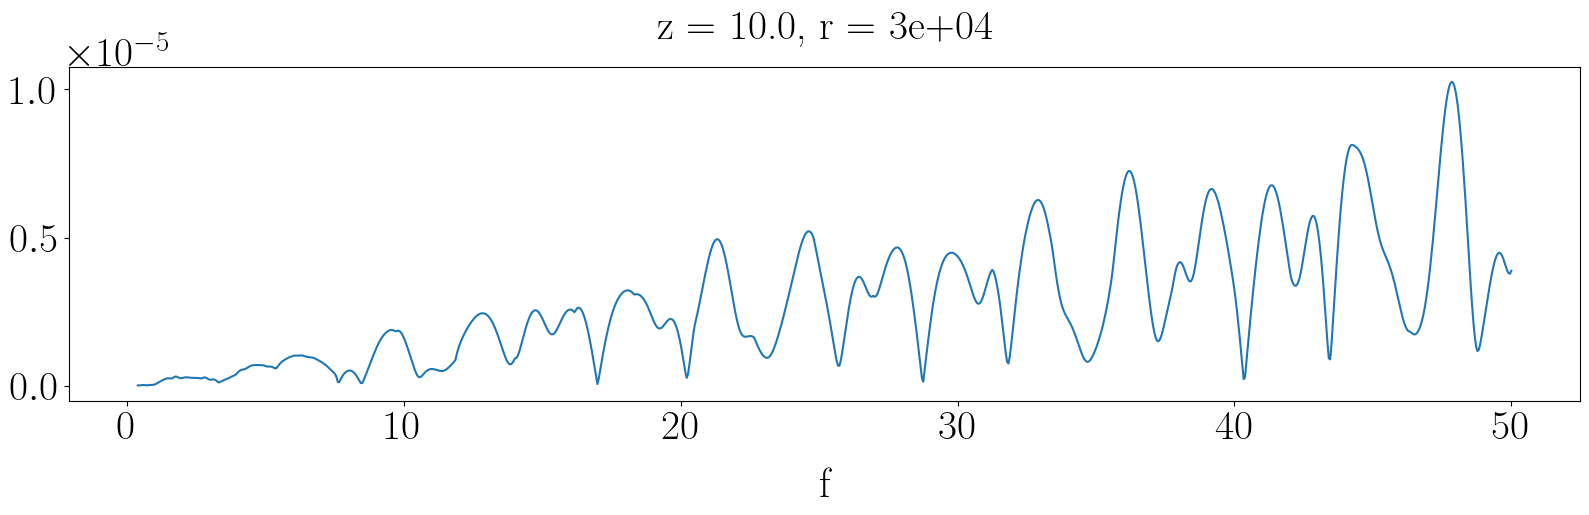

In [288]:
r_plot = 30 * 1e3
z_plot = 10
tf_pos = ds_tf.sel(r=r_plot, z=z_plot, method="nearest").tf_real + 1j * ds_tf.sel(r=r_plot, z=z_plot, method="nearest").tf_imag

k0 = 2 * np.pi * ds_tf.f.values / g.c0
norm_factor = np.exp(1j * k0) / (4 * np.pi)
tf_pos *= norm_factor


lfig = LargeFigure()
plt.figure()
np.abs(tf_pos).plot(x="f", color="C0")

# Génération des jeux de données pour chacun des cas test 

## Cas test 0 : démo avec un pulse 

In [289]:
# Extract testcase info
i_tc = 0
sig_name = testcase_infos[i_tc]["name"]
sig_fpath = testcase_infos[i_tc]["sig_fpath"]
hla_sig_fpath = testcase_infos[i_tc]["hla_sig_fpath"]

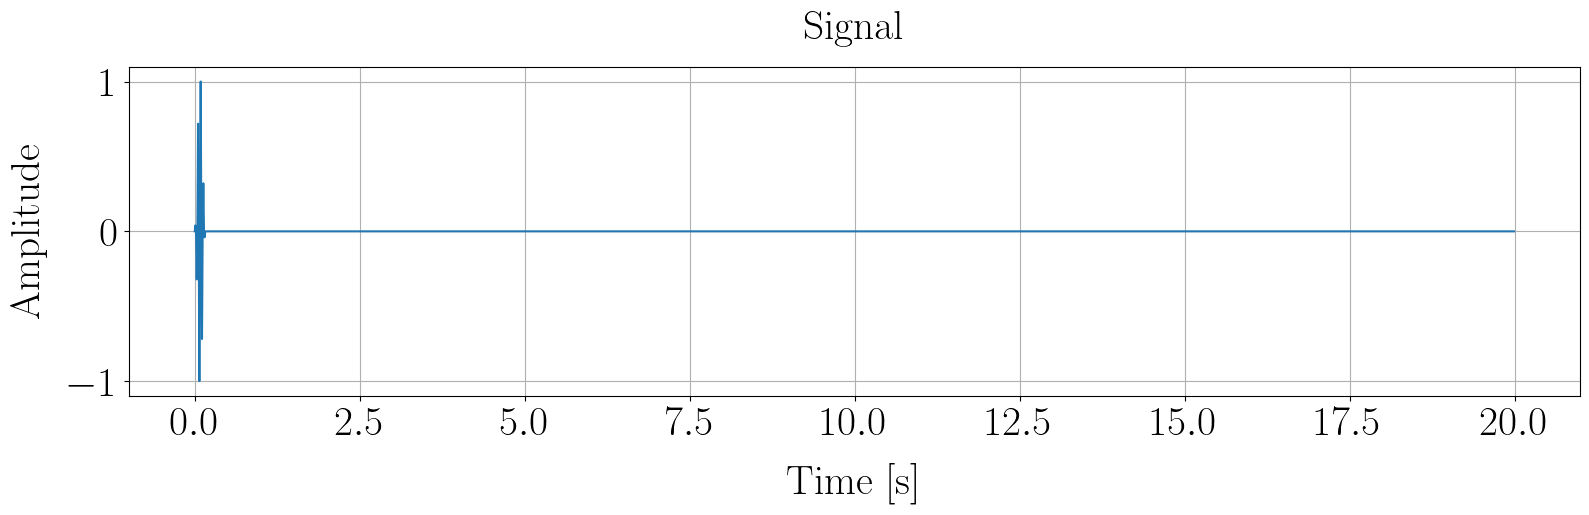

In [290]:
# Define source signal
fc = 25
s, t = sg.pulse(T=src_signal_duration, fc=fc, fs=src_fs, t0=0)
s = sg.normalize_sig(s, normalize="max")

# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Pulse",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

<Figure size 1600x525 with 0 Axes>

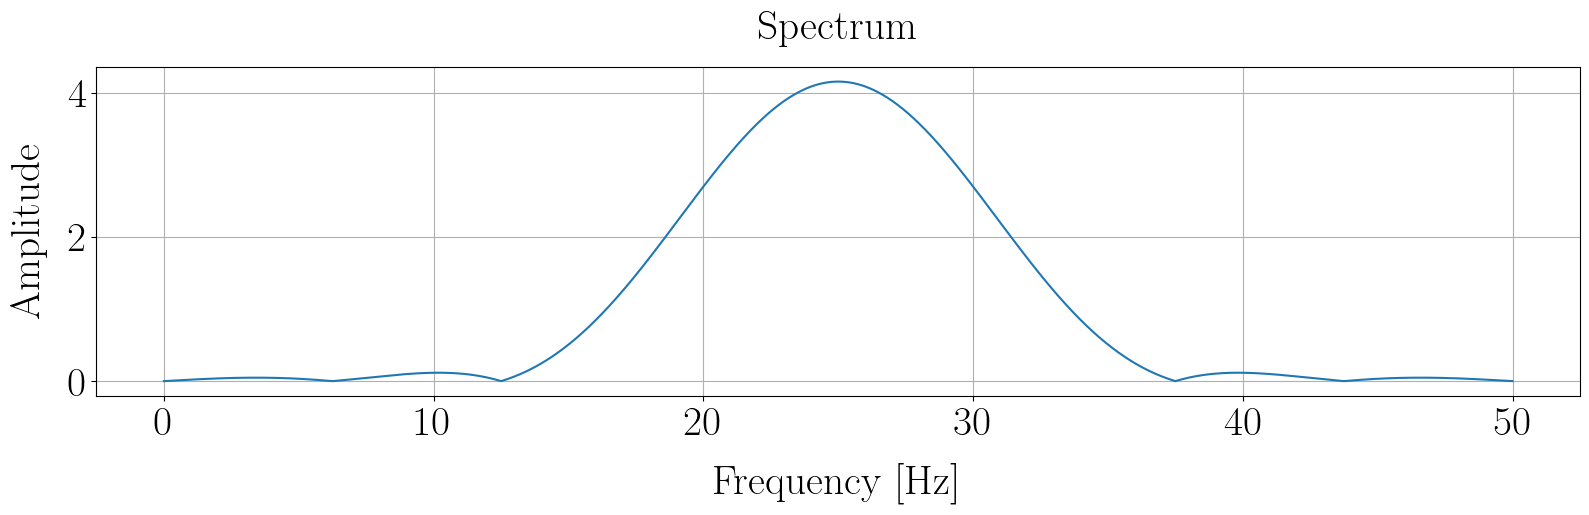

In [291]:
# Plot spectrum 
plt.figure()

sg.plot_spectrum(src.positive_freq, src.positive_spectrum)


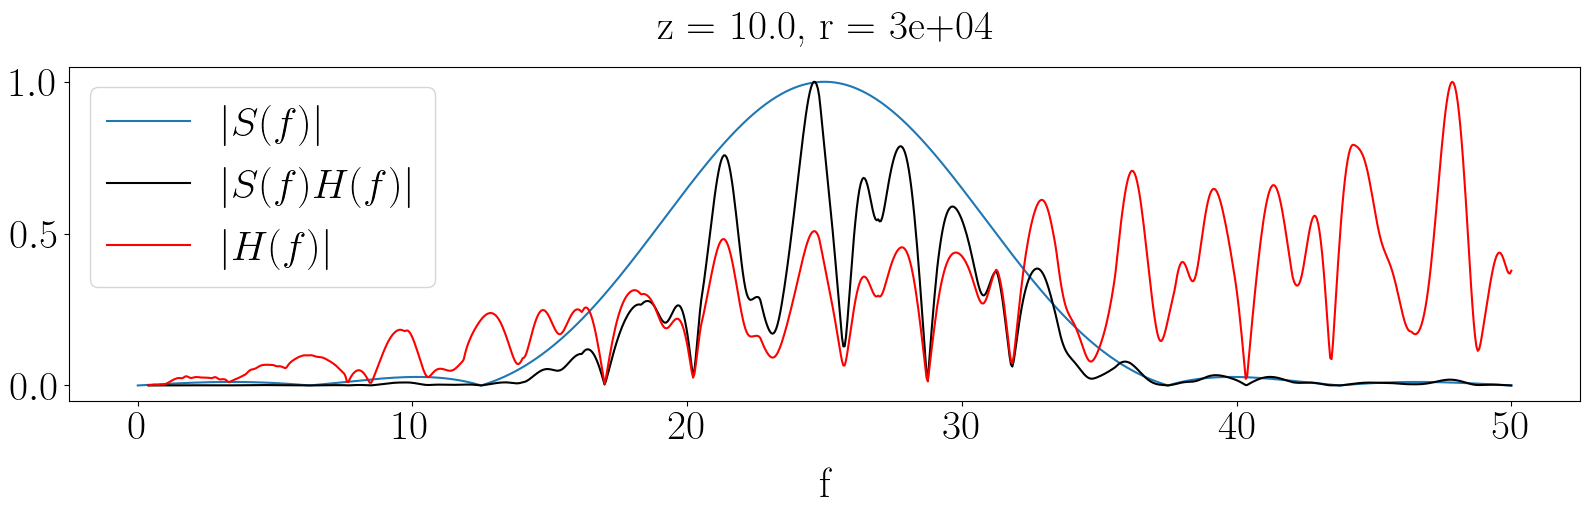

In [292]:
# Plot Sf * tf
Sf = src.positive_spectrum
fmin = np.min(ds_tf.f.values)
idx_first_freq = np.argmin(np.abs(src.positive_freq - fmin))
Sf = Sf[idx_first_freq:]
y_f = tf_pos * Sf

plt.figure()
plt.plot(
    src.positive_freq,
    np.abs(src.positive_spectrum) / np.max(np.abs(src.positive_spectrum)
                                           ),
    label="$|S(f)|$",
)
plt.plot(ds_tf.f, np.abs(y_f) / np.max(np.abs(y_f)), color="k", label="$|S(f)H(f)|$")
(np.abs(tf_pos) / np.max(np.abs(tf_pos))).plot(x="f", label=r"$|H(f)|$", color="r")
plt.legend()

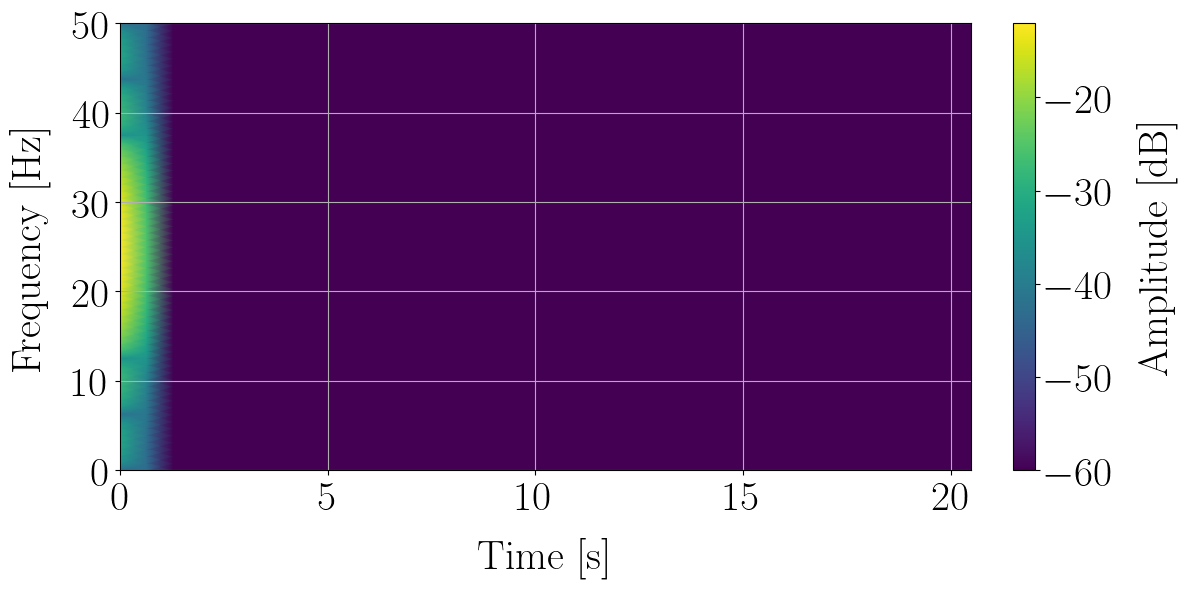

In [293]:
# Derive and plot STFT
window = "hann"
nperseg = 2**7
noverlap = 2**6
ff, tt, Sxx = sp.stft(
    s,
    fs=src_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx[Sxx == 0] = 1e-6  # To avoid log of zero
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud")
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()

In [294]:
# Subsample transfer function dataset to reduce memory usage
rcv_rmin = ds_tf.r.min().values 
rcv_rmax = ds_tf.r.max().values
rcv_dr = 100
rcv_range = np.arange(rcv_rmin, rcv_rmax + rcv_dr, rcv_dr)

rcv_zmin = ds_tf.z.min().values
rcv_zmax = 200
rcv_dz = 10
rcv_depth = np.arange(rcv_zmin, rcv_zmax + rcv_dz, rcv_dz)

t, y_t, ds_sig = propagate_sig(tf_xr=ds_tf, src=src, rcv_range=rcv_range, rcv_depth=rcv_depth)

In [295]:
# Set dataset attributes and save it
ds_sig.attrs = {
    "fs": src_fs,
    "signal_duration": src_signal_duration,
    "source_type": "pulse",
}
# ds_sig.to_netcdf(sig_fpath)

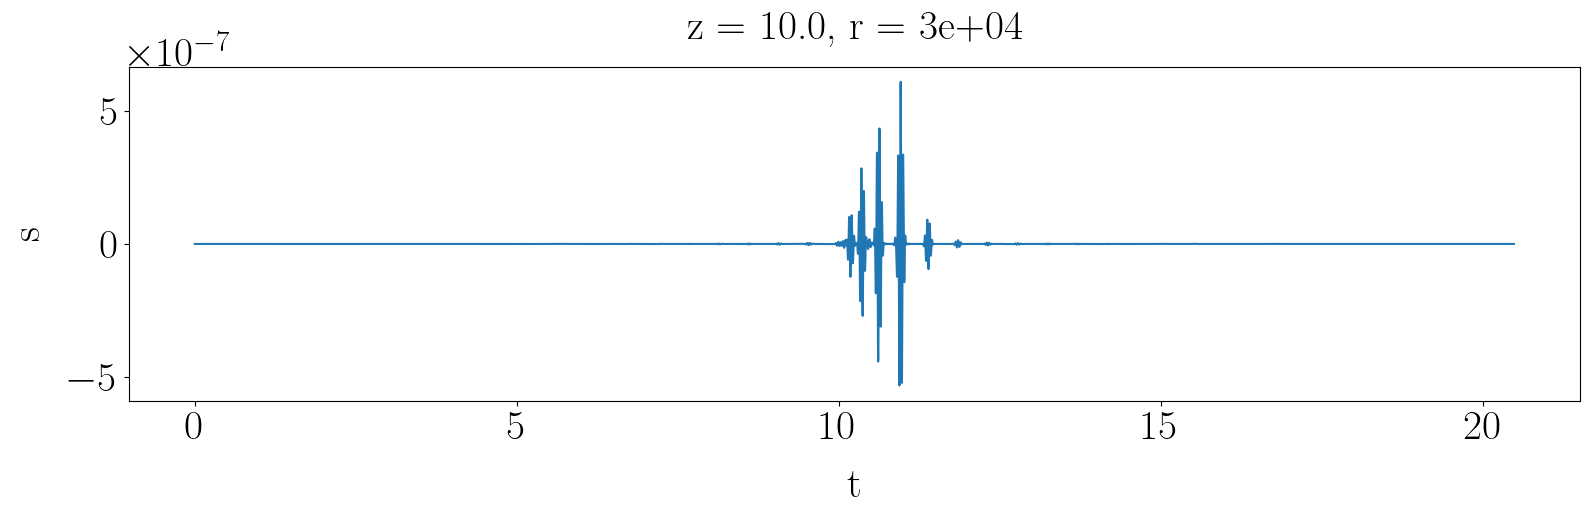

In [296]:
# Plot the propagated signal to check the result
lfig = LargeFigure()

r_plot = 30 * 1e3
z_plot = 10
ds_sig.sel(r=r_plot, z=z_plot).s.plot()

### Check every thing is ok 


(0.0, 50.0)

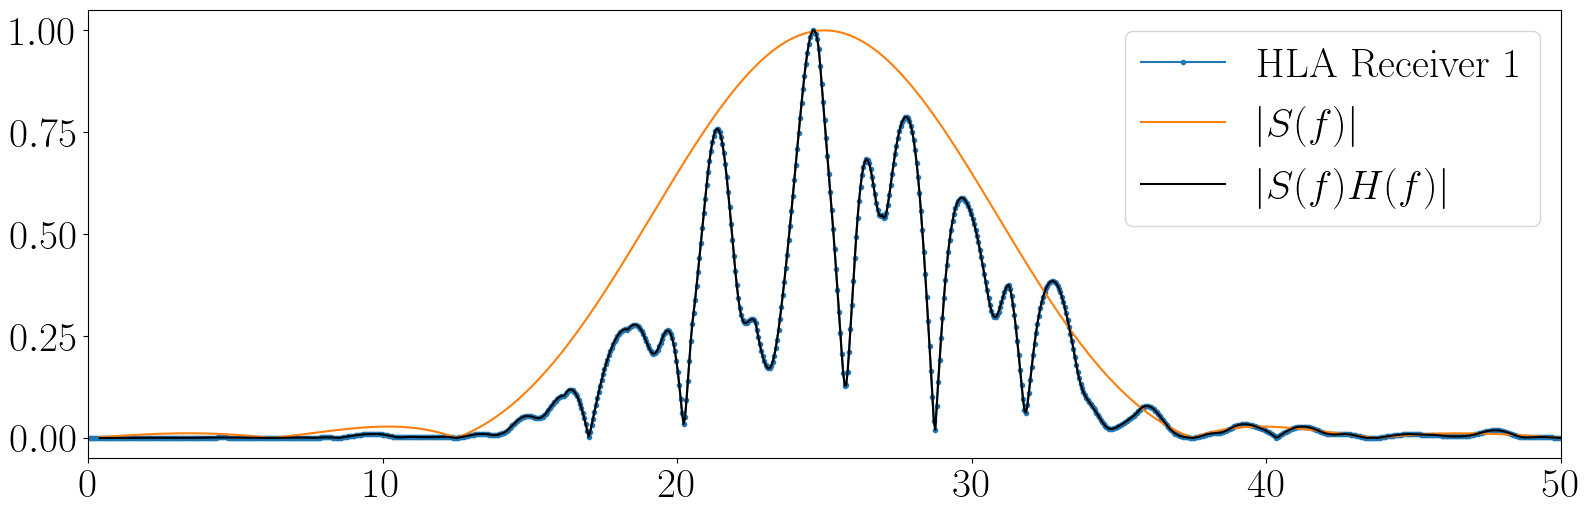

In [297]:
# Plot spectrums
r_plot = 30 * 1e3
z_plot = 10


# Sf * tf
Sf = src.positive_spectrum
fmin = np.min(ds_tf.f.values)
idx_first_freq = np.argmin(np.abs(src.positive_freq - fmin))
Sf = Sf[idx_first_freq:]
f_Sf = src.positive_freq[idx_first_freq:]
y_f = tf_pos * Sf

nfft_inv = 4 * src.nfft
ts = ds_sig.diff("t").t.values[0]

sig_0 = ds_sig.s.sel(r=r_plot, z=z_plot)
y_f_0 = np.fft.rfft(sig_0)
sig_0_f = np.fft.rfftfreq(sig_0.t.size, d=ts)


plt.figure()
plt.plot(sig_0_f, np.abs(y_f_0) / np.max(np.abs(y_f_0)), label="HLA Receiver 1", marker="o", markersize=3)
plt.plot(
    f_Sf,
    np.abs(Sf) / np.max(np.abs(Sf)),
    label="$|S(f)|$",
)
plt.plot(
    f_Sf,
    np.abs(y_f) / np.max(np.abs(y_f)),
    color="k",
    label="$|S(f)H(f)|$",
)

plt.legend()
plt.xlim([0,50]) 
# plt.ylim([-0.01,0.01])

(0.0, 50.0)

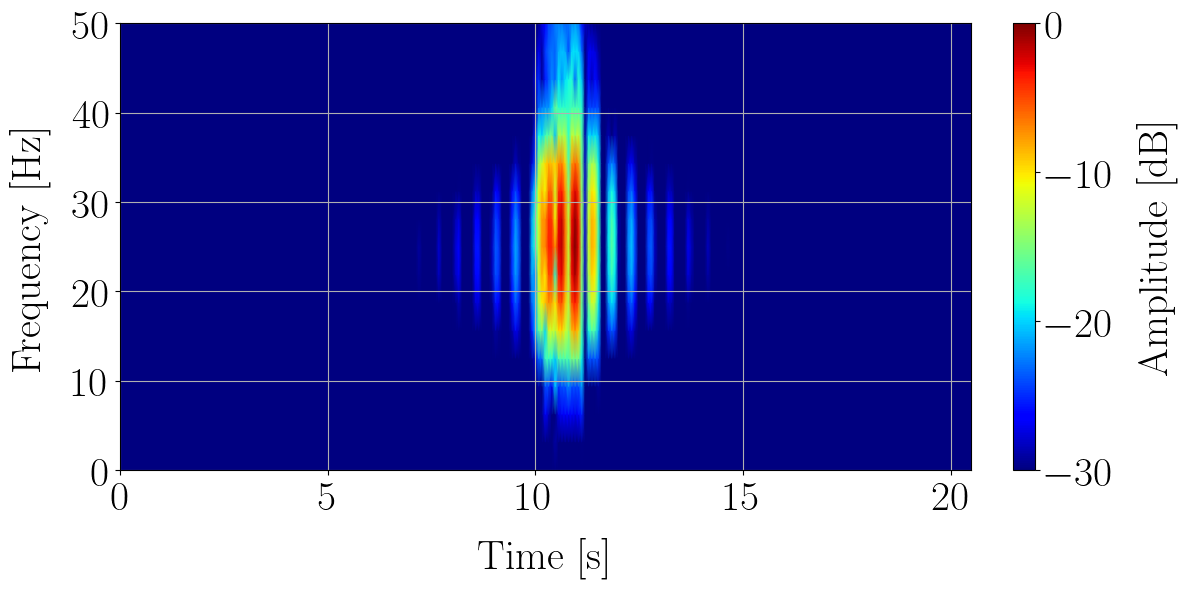

In [298]:
# Derive and plot STFT
window = "hann"
nperseg = 2**7
noverlap = nperseg * 3 // 4
ff, tt, Sxx = sp.stft(
    ds_sig.s.sel(r=r_plot, z=z_plot),
    fs=1/ts,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-30, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()
plt.ylim([0, 50])

In [299]:
hla_delta_r_rcv = 100  # Receiver range step in meters
hla_nrcv = 5  # Number of receivers in the HLA
hla_sig_grid, hla_rtf_grid = build_hla_features(
    tf_xr=ds_tf,
    src=src,
    delta_r_rcv=hla_delta_r_rcv,
    rcv_range=rcv_range,
    rcv_depth=rcv_depth,
    n_rcv=hla_nrcv,
    rmin=None,
    rmax=None,
    z_src=src_depth     
)

# Get output fs
z_ts = hla_sig_grid.diff("t").t.values[0]
z_fs = 1 / z_ts

In [300]:
# Save HLA features
hla_sig_grid.attrs = {
    "fs": z_fs,
    "signal_duration": src_signal_duration,
    "source_type": sig_name,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,     # Because of reciprocity this actually represent the HLA receiver depth
}
hla_rtf_grid.attrs = {
    "fs": src_fs,
    "signal_duration": src_signal_duration,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
}
hla_sig_grid.to_netcdf(hla_sig_fpath)
hla_rtf_grid.to_netcdf(hla_rtf_fpath)

## Plot received signals 

Text(0, 0.5, 'Amplitude')

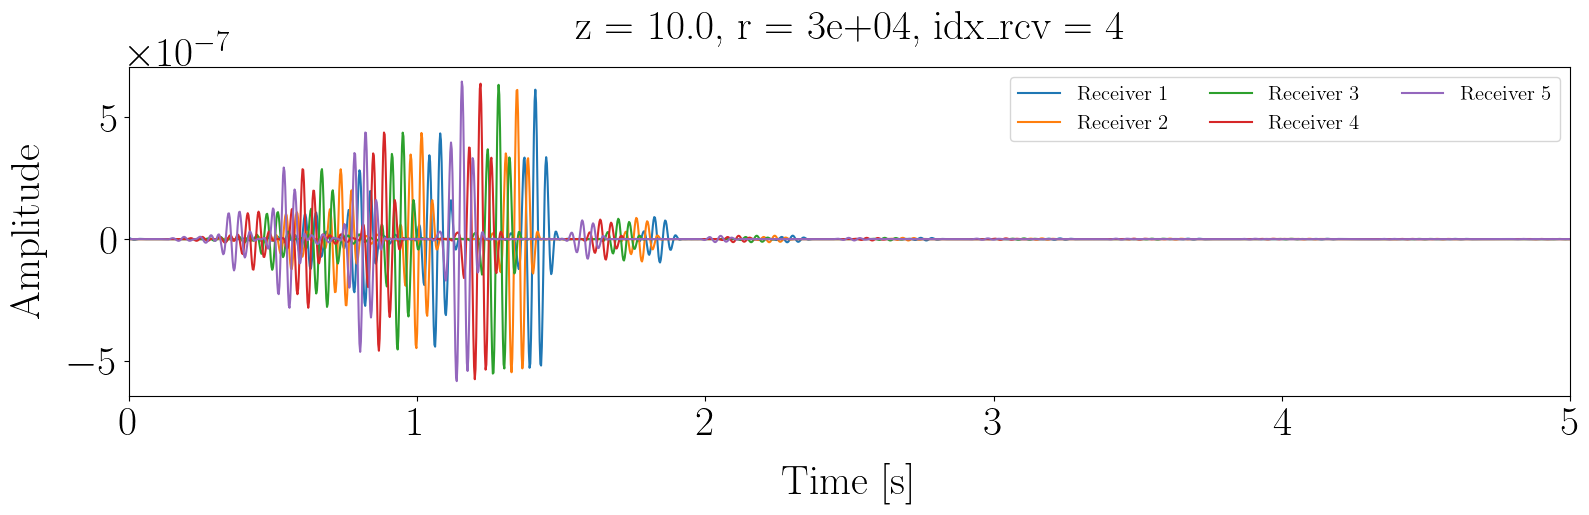

In [301]:
# Visualize signals at each receiver
r_plot = 30 * 1e3
z_plot = 10

lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
plt.xlim([0, 5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

(0.0, 50.0)

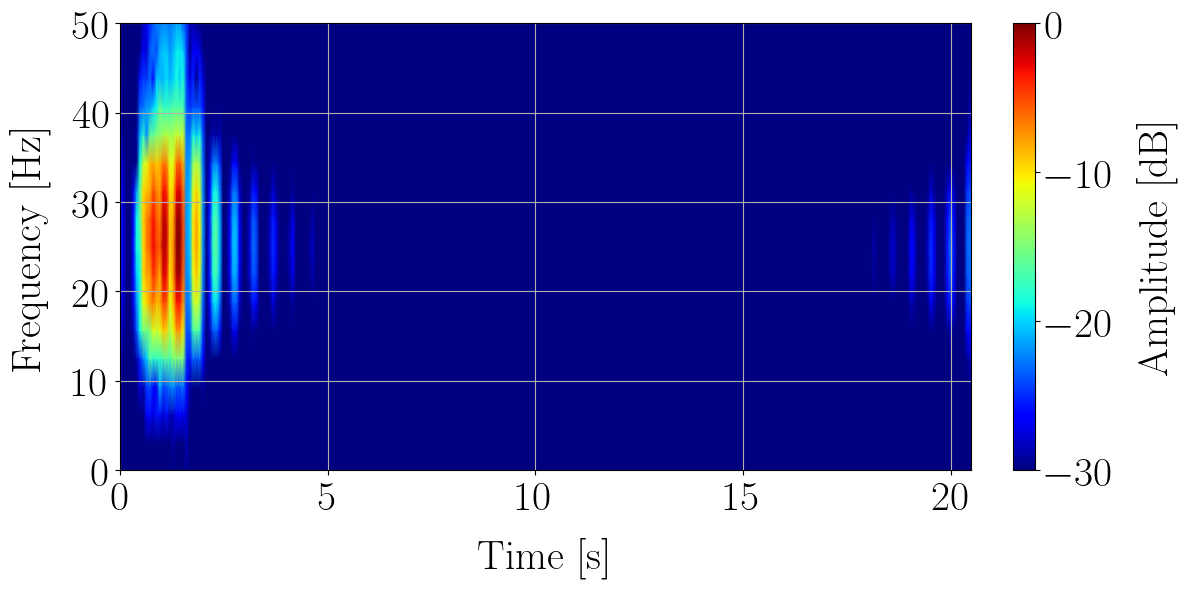

In [302]:
# Derive and plot STFT
window = "hann"
nperseg = 2**7
noverlap = 2**7 * 3//4
ff, tt, Sxx = sp.stft(
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=0),
    fs=z_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-30, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()
plt.ylim([0, 50])
# plt.xlim([0, 10])

## Plot associated RTF (true) 

Text(0.5, 1.0, 'Range = 30.0 km, Depth = 10 m')

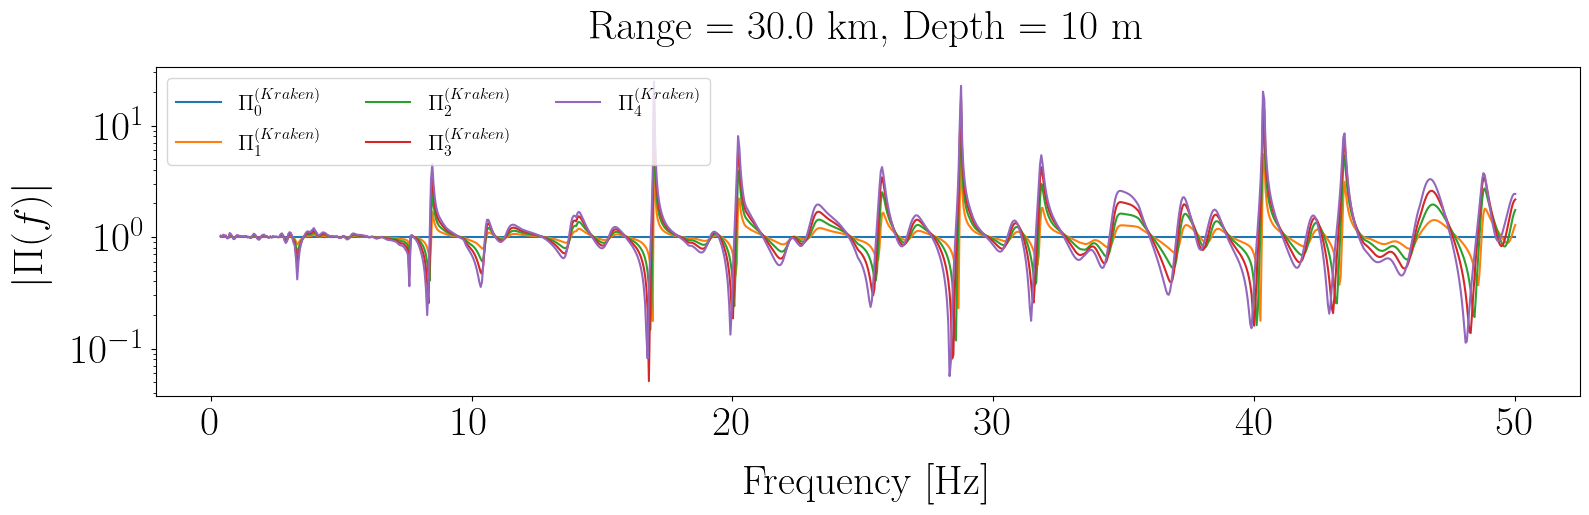

In [303]:
lfig = LargeFigure()

hla_rtf_pos = hla_rtf_grid.rtf_real.sel(r=r_plot, z=z_plot) + 1j * hla_rtf_grid.rtf_imag.sel(r=r_plot, z=z_plot)

plt.figure()
for i in range(hla_nrcv):
    np.abs(hla_rtf_pos.sel(idx_rcv=i)).plot(label=r"$\Pi_{" + str(i) + r"}^{(Kraken)}$"),

# plt.xscale()
plt.yscale("log")
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|\Pi(f)|$")
plt.legend(fontsize=16, ncols=3)
plt.title(f"Range = {r_plot/1e3} km, Depth = {z_plot} m")

## Cas test 1 : bruit blanc 

In [ ]:
# Extract testcase info
i_tc = 1
sig_name = testcase_infos[i_tc]["name"]
sig_fpath = testcase_infos[i_tc]["sig_fpath"]
hla_sig_fpath = testcase_infos[i_tc]["hla_sig_fpath"]

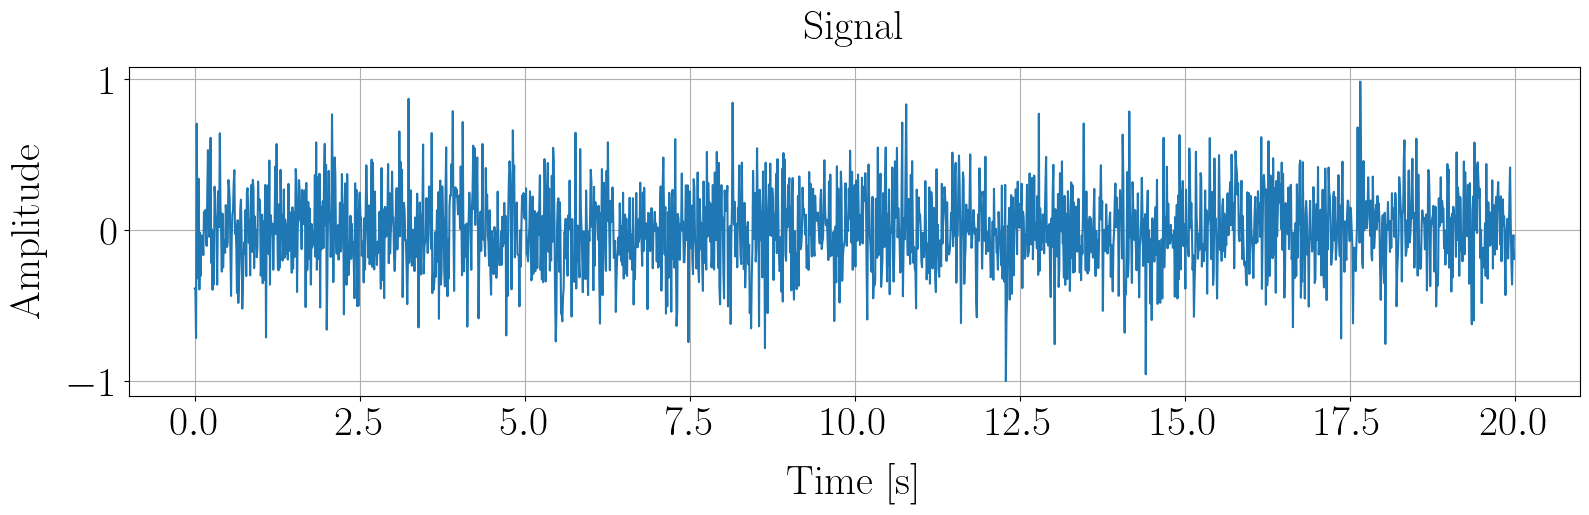

In [305]:
# Define source signal
fc = 25
t, s = sg.colored_noise(T=src_signal_duration, fs=src_fs, noise_color="white")
s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="White noise",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

In [306]:
hla_delta_r_rcv = 100  # Receiver range step in meters
hla_nrcv = 5  # Number of receivers in the HLA
hla_sig_grid, _ = build_hla_features(
    tf_xr=ds_tf,
    src=src,
    delta_r_rcv=hla_delta_r_rcv,
    rcv_range=rcv_range,
    rcv_depth=rcv_depth,
    n_rcv=hla_nrcv,
    rmin=None,
    rmax=None,
)

# Get output fs
z_ts = hla_sig_grid.diff("t").t.values[0]
z_fs = 1 / z_ts

Text(0, 0.5, 'Amplitude')

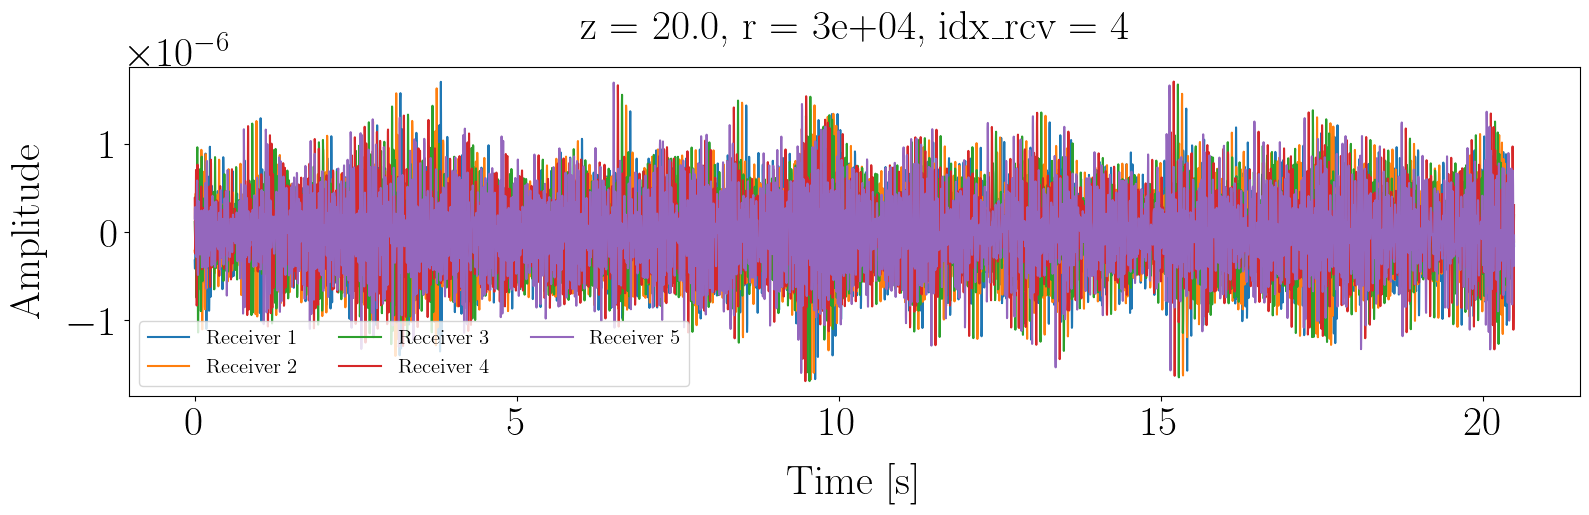

In [307]:
# Visualize signals at each receiver
r_plot = 30 * 1e3
z_plot = 20

lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
# plt.xlim([9.5, 11.5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

In [308]:
# Save HLA features
hla_sig_grid.attrs = {
    "fs": z_fs,
    "signal_duration": src_signal_duration,
    "source_type": sig_name,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
}
hla_sig_grid.to_netcdf(hla_sig_fpath)

## Cas test 2 : pink noise

In [ ]:
# Extract testcase info
i_tc = 2
sig_name = testcase_infos[i_tc]["name"]
sig_fpath = testcase_infos[i_tc]["sig_fpath"]
hla_sig_fpath = testcase_infos[i_tc]["hla_sig_fpath"]

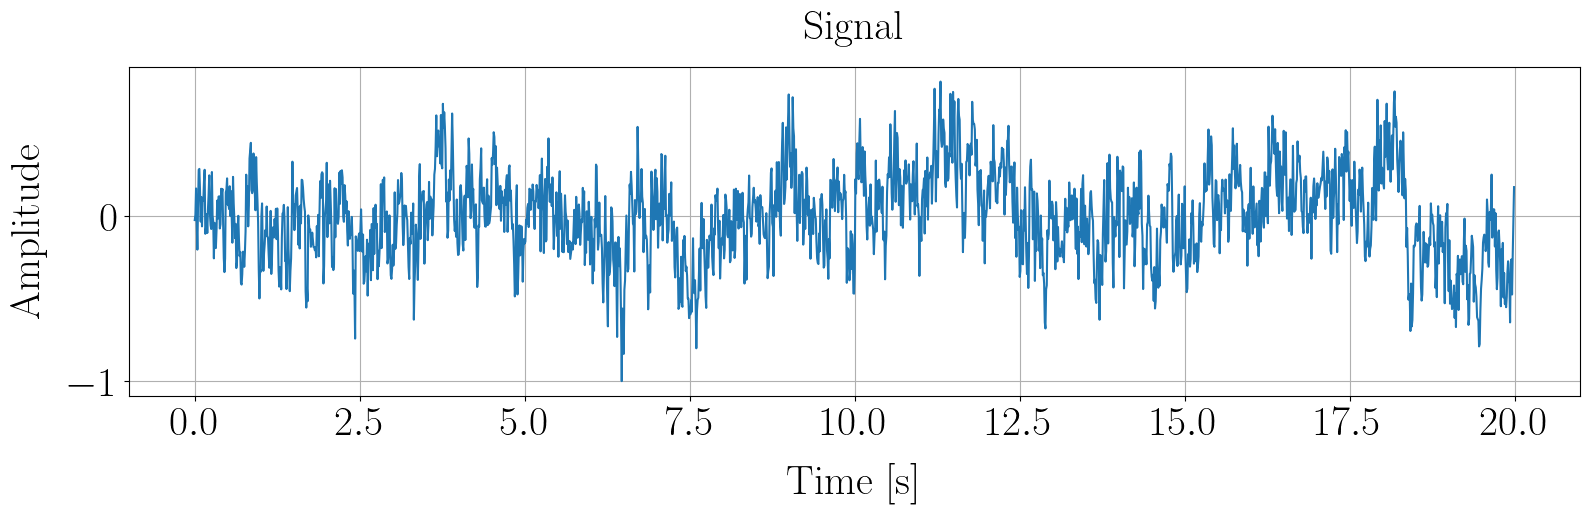

In [310]:
# Define source signal
fc = 25
t, s = sg.colored_noise(T=src_signal_duration, fs=src_fs, noise_color="pink")
s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Pink noise",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

In [311]:
hla_delta_r_rcv = 100  # Receiver range step in meters
hla_nrcv = 5  # Number of receivers in the HLA
hla_sig_grid, _ = build_hla_features(
    tf_xr=ds_tf,
    src=src,
    delta_r_rcv=hla_delta_r_rcv,
    rcv_range=rcv_range,
    rcv_depth=rcv_depth,
    n_rcv=hla_nrcv,
    rmin=None,
    rmax=None,
)

# Get output fs
z_ts = hla_sig_grid.diff("t").t.values[0]
z_fs = 1 / z_ts

Text(0, 0.5, 'Amplitude')

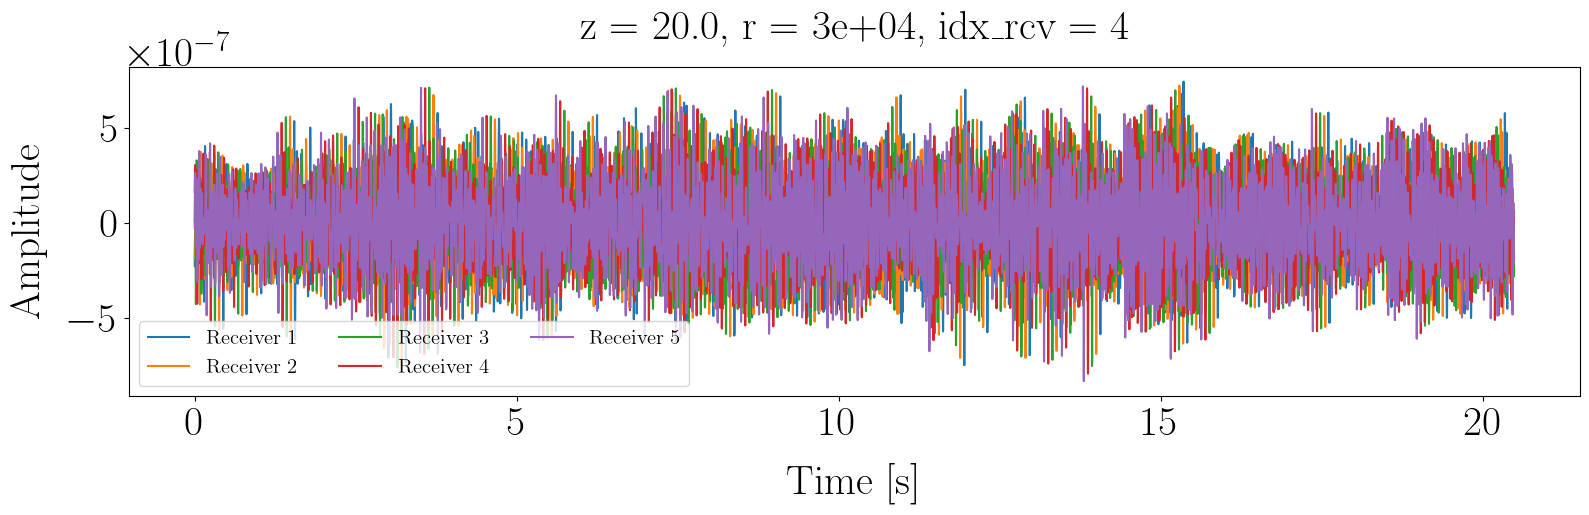

In [312]:
# Visualize signals at each receiver
r_plot = 30 * 1e3
z_plot = 20

lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
# plt.xlim([9.5, 11.5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

In [313]:
# Save HLA features
hla_sig_grid.attrs = {
    "fs": z_fs,
    "signal_duration": src_signal_duration,
    "source_type": sig_name,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
}
hla_sig_grid.to_netcdf(hla_sig_fpath)

## Cas test 3 : LFM

In [ ]:
# Extract testcase info
i_tc = 3
sig_name = testcase_infos[i_tc]["name"]
sig_fpath = testcase_infos[i_tc]["sig_fpath"]
hla_sig_fpath = testcase_infos[i_tc]["hla_sig_fpath"]

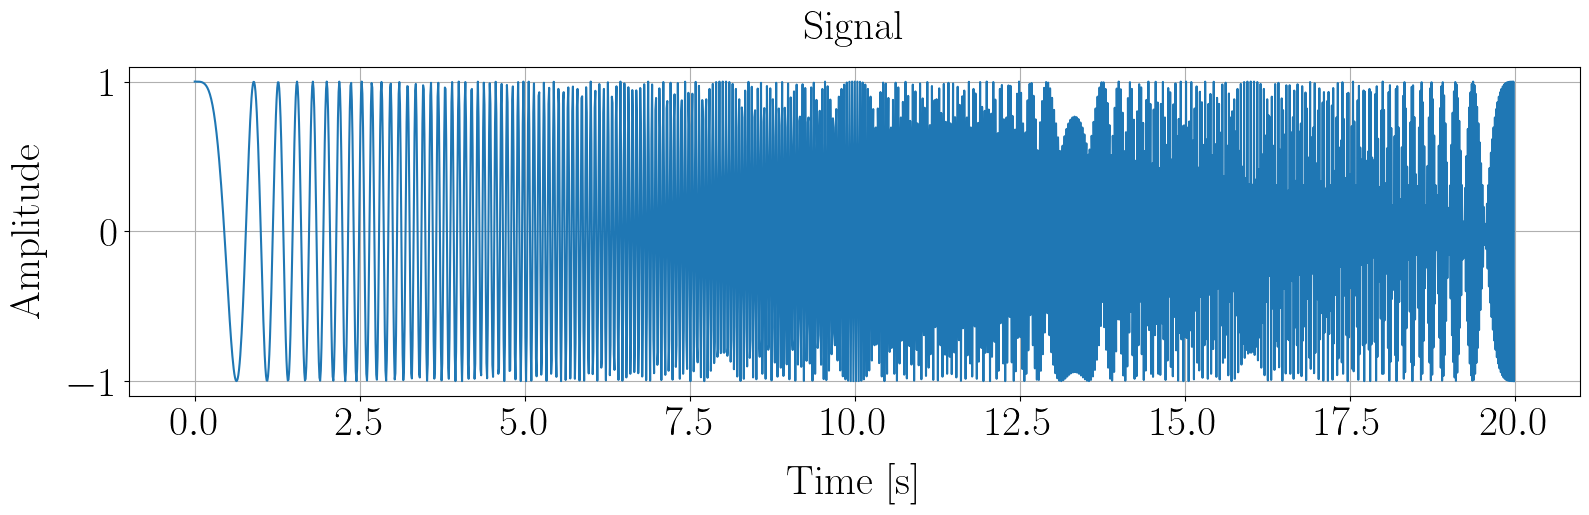

In [315]:
# Define source signal
f0 = 0
f1 = 50
t, s = sg.lfm_chirp(f0=f0, f1=f1, fs=src_fs, T=src_signal_duration, phi=0)

s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Chirp LFM",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

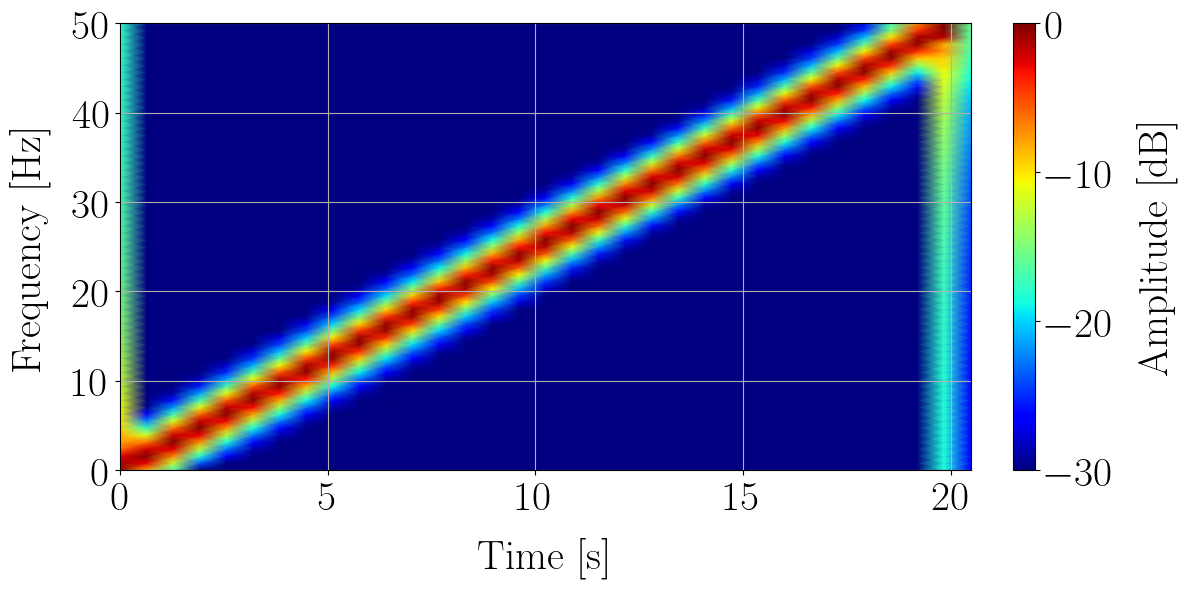

In [316]:
# Derive and plot STFT
window="hann"
nperseg=2**7
noverlap=2**6
ff, tt, Sxx = sp.stft(
    s, fs=src_fs, window=window, nperseg=nperseg, noverlap=noverlap
)

Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-30, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()


In [317]:
hla_delta_r_rcv = 100  # Receiver range step in meters
hla_nrcv = 5  # Number of receivers in the HLA
hla_sig_grid, _ = build_hla_features(
    tf_xr=ds_tf,
    src=src,
    delta_r_rcv=hla_delta_r_rcv,
    rcv_range=rcv_range,
    rcv_depth=rcv_depth,
    n_rcv=hla_nrcv,
    rmin=None,
    rmax=None,
)

# Get output fs
z_ts = hla_sig_grid.diff("t").t.values[0]
z_fs = 1 / z_ts

Text(0, 0.5, 'Amplitude')

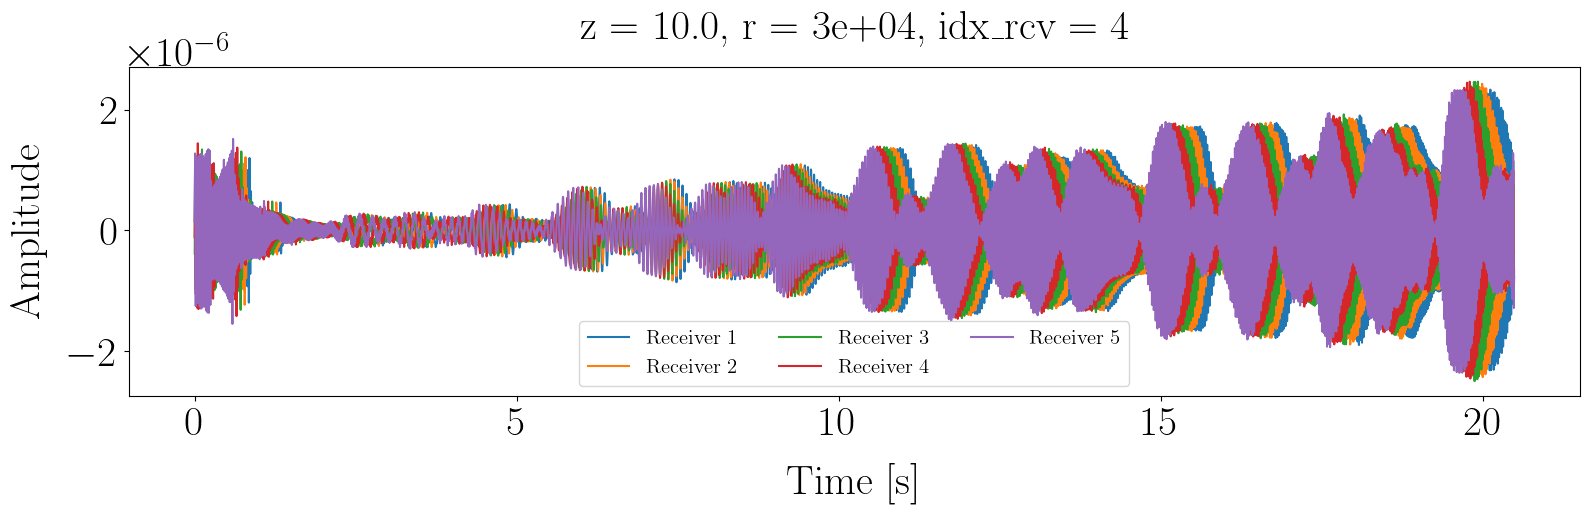

In [318]:
# Visualize signals at each receiver
r_plot = 30 * 1e3
z_plot = 10

lfig = LargeFigure()
plt.figure()
for i in range(hla_nrcv):
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=i).plot(label=f"Receiver {i+1}")
# plt.xlim([9.5, 11.5])
plt.legend(ncols=3, fontsize=15)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

In [319]:
# Save HLA features
hla_sig_grid.attrs = {
    "fs": z_fs,
    "signal_duration": src_signal_duration,
    "source_type": sig_name,
    "antenna": "HLA",
    "delta_r_rcv": hla_delta_r_rcv,
    "n_rcv": hla_nrcv,
    "hla_depth": src_depth,  # Because of reciprocity this actually represent the HLA receiver depth
}
hla_sig_grid.to_netcdf(hla_sig_fpath)

(0.0, 50.0)

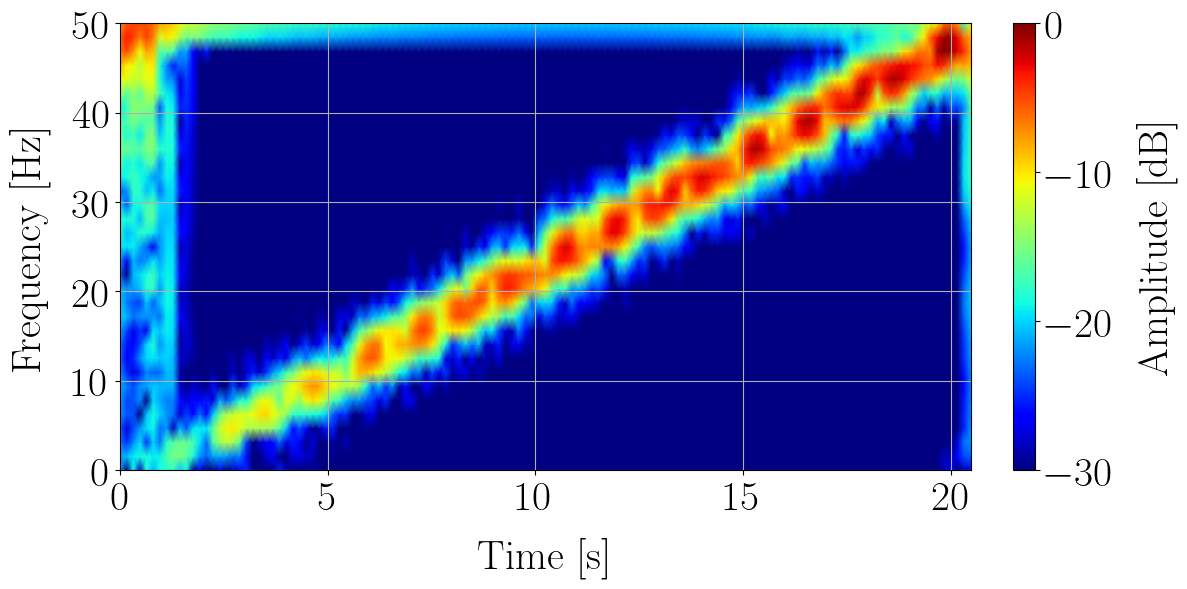

In [326]:
# Derive and plot STFT
window="hann"
nperseg=2**8
noverlap=nperseg * 3//4
ff, tt, Sxx = sp.stft(
    hla_sig_grid.s.sel(r=r_plot, z=z_plot, idx_rcv=2),
    fs=z_fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
)
Sxx /= np.max(np.abs(Sxx))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    tt, ff, 10 * np.log10(np.abs(Sxx)), shading="gouraud", vmin=-30, vmax=-0, cmap="jet"
)
# ax.set_title(self.name)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
plt.colorbar(im, label="Amplitude [dB]", ax=ax)
ax.grid()
plt.ylim([0, 50])

# Estimation des vecteurs de RTF

## Load all usefull dataset (to prevent rerunning previous cells)

In [69]:
# First ensure all datasets are closed 
if "hla_sig_grid" in locals():
    hla_sig_grid.close()
    del hla_sig_grid
if "ds_sig"in locals():
    ds_sig.close()
    del ds_sig

testcase_data = {}
for i_tc in testcase_infos.keys():
    ds = xr.open_dataset(testcase_infos[i_tc]["hla_sig_fpath"])
    testcase_data[i_tc] = ds

In [70]:
testcase_data

{0: <xarray.Dataset> Size: 2GB
 Dimensions:  (t: 8192, z: 21, r: 297, idx_rcv: 5)
 Coordinates:
   * t        (t) float64 66kB 0.0 0.0025 0.005 0.0075 ... 20.47 20.48 20.48
   * z        (z) float32 84B 0.0 10.0 20.0 30.0 40.0 ... 170.0 180.0 190.0 200.0
   * r        (r) float64 2kB 1.54e+04 1.55e+04 1.56e+04 ... 4.49e+04 4.5e+04
   * idx_rcv  (idx_rcv) int32 20B 0 1 2 3 4
 Data variables:
     s        (t, z, r, idx_rcv) float64 2GB ...
 Attributes:
     fs:               400.0
     signal_duration:  20.0
     source_type:      pulse
     antenna:          HLA
     delta_r_rcv:      100
     n_rcv:            5
     hla_depth:        999.0,
 1: <xarray.Dataset> Size: 2GB
 Dimensions:  (t: 8192, z: 21, r: 297, idx_rcv: 5)
 Coordinates:
   * t        (t) float64 66kB 0.0 0.0025 0.005 0.0075 ... 20.47 20.48 20.48
   * z        (z) float32 84B 0.0 10.0 20.0 30.0 40.0 ... 170.0 180.0 190.0 200.0
   * r        (r) float64 2kB 1.54e+04 1.55e+04 1.56e+04 ... 4.49e+04 4.5e+04
   * idx_rcv  (i

In [71]:
# Load HLA RTF
if "hla_rtf_grid" in locals():
    hla_rtf_grid.close()
    del hla_rtf_grid
ds_hla_rtf = xr.open_dataset(hla_rtf_fpath)

In [72]:
ds_hla_rtf

<xarray.Dataset> Size: 507MB
Dimensions:   (f: 1017, z: 21, r: 297, idx_rcv: 5)
Coordinates:
  * f         (f) float64 8kB 0.3906 0.4395 0.4883 0.5371 ... 49.9 49.95 50.0
  * z         (z) float32 84B 0.0 10.0 20.0 30.0 ... 170.0 180.0 190.0 200.0
  * r         (r) float64 2kB 1.54e+04 1.55e+04 1.56e+04 ... 4.49e+04 4.5e+04
  * idx_rcv   (idx_rcv) int32 20B 0 1 2 3 4
Data variables:
    rtf_real  (f, z, r, idx_rcv) float64 254MB ...
    rtf_imag  (f, z, r, idx_rcv) float64 254MB ...
Attributes:
    fs:               100
    signal_duration:  20.0
    antenna:          HLA
    delta_r_rcv:      100
    n_rcv:            5
    hla_depth:        999.0

## Define analysis params 

In [73]:
delta_snr = 1
snr_min = -5
snr_max = 5
snrs = np.arange(snr_min, snr_max + delta_snr, delta_snr)

idx_rcv_ref = 0

In [74]:
z_fs = testcase_data[0].attrs["fs"]
cov_snapshot_duration = 3   # Duration of the time window to compute the covariance matrix in seconds (should be greater than the impulse response duration)
cov_snapshot_size = int(cov_snapshot_duration * z_fs)  # Number of samples in the time window to compute the covariance matrix
nperseg = 2 ** int(np.log2(cov_snapshot_size) + 1)
noverlap = nperseg // 2
window = "hann"

print(f"Cov snapshot duration: {cov_snapshot_duration} s")
print(f"Associated nperseg: {nperseg} samples")
print(f"Associated noverlap: {noverlap} samples")


Cov snapshot duration: 3 s
Associated nperseg: 2048 samples
Associated noverlap: 1024 samples


In [75]:
# Position where rtf are estimated
r_hat = 30 * 1e3
z_hat = 10

## Initialize RTF estimation tools 

In [76]:
rtf_estimator = RTFEstimator(
    fs=testcase_data[0].attrs["fs"],
    idx_rcv_ref=idx_rcv_ref,
    nperseg=nperseg,
    noverlap=noverlap,
    window=window,
)

In [77]:
# Restrict data to the required position
for i_tc in testcase_data.keys():
    testcase_data[i_tc] = testcase_data[i_tc].sel(r=slice(r_hat, r_hat+0.1), z=slice(z_hat, z_hat+0.1))     # slice +0.1 to keep dimensions 
    # testcase_data[i_tc] = testcase_data[i_tc].sel(r=r_hat, z=z_hat, method="nearest")     # slice +0.1 to keep dimensions

z_fs = testcase_data[0].attrs["fs"]
hla_nrcv = testcase_data[0].attrs["n_rcv"]
# RTF
ds_hla_rtf = ds_hla_rtf.sel(r=r_hat, z=z_hat, method="nearest")  # slice +0.1 to keep dimensions

In [78]:
testcase_data

{0: <xarray.Dataset> Size: 393kB
 Dimensions:  (t: 8192, z: 1, r: 1, idx_rcv: 5)
 Coordinates:
   * t        (t) float64 66kB 0.0 0.0025 0.005 0.0075 ... 20.47 20.48 20.48
   * z        (z) float32 4B 10.0
   * r        (r) float64 8B 3e+04
   * idx_rcv  (idx_rcv) int32 20B 0 1 2 3 4
 Data variables:
     s        (t, z, r, idx_rcv) float64 328kB ...
 Attributes:
     fs:               400.0
     signal_duration:  20.0
     source_type:      pulse
     antenna:          HLA
     delta_r_rcv:      100
     n_rcv:            5
     hla_depth:        999.0,
 1: <xarray.Dataset> Size: 393kB
 Dimensions:  (t: 8192, z: 1, r: 1, idx_rcv: 5)
 Coordinates:
   * t        (t) float64 66kB 0.0 0.0025 0.005 0.0075 ... 20.47 20.48 20.48
   * z        (z) float32 4B 10.0
   * r        (r) float64 8B 3e+04
   * idx_rcv  (idx_rcv) int32 20B 0 1 2 3 4
 Data variables:
     s        (t, z, r, idx_rcv) float64 328kB ...
 Attributes:
     fs:               400.0
     signal_duration:  20.0
     source_type

In [79]:
ds_hla_rtf

<xarray.Dataset> Size: 90kB
Dimensions:   (f: 1017, idx_rcv: 5)
Coordinates:
  * f         (f) float64 8kB 0.3906 0.4395 0.4883 0.5371 ... 49.9 49.95 50.0
    z         float32 4B 10.0
    r         float64 8B 3e+04
  * idx_rcv   (idx_rcv) int32 20B 0 1 2 3 4
Data variables:
    rtf_real  (f, idx_rcv) float64 41kB ...
    rtf_imag  (f, idx_rcv) float64 41kB ...
Attributes:
    fs:               100
    signal_duration:  20.0
    antenna:          HLA
    delta_r_rcv:      100
    n_rcv:            5
    hla_depth:        999.0

In [80]:
rtf_kraken = ds_hla_rtf.rtf_real + 1j * ds_hla_rtf.rtf_imag

## Test with a single SNR to ensure everything is ok 

### Compute and add noise vector 

In [81]:
snr_test = 0
z_xr = testcase_data[2]
noise, noise_mix = generate_noise(z_xr.s, snr=snr_test, idx_rcv_ref=0)

noisy_signal = z_xr.s + noise_mix
noise_only = noise

noisy_signal = noisy_signal.squeeze()
noise_only = noise_only.squeeze()

In [82]:
f, rtf_cs_evd, Rx_evd, Rv_evd = rtf_estimator.covariance_subtraction(
    noisy_signal=noisy_signal,
    noise_only=noise_only,
    use_first_column=False,
    add_id_x=False,
    add_id_v=False,
)

f, rtf_cs_fc, Rx_fc, Rv_fc = rtf_estimator.covariance_subtraction(
    noisy_signal=noisy_signal,
    noise_only=noise_only,
    use_first_column=True,
    add_id_x=False,
    add_id_v=False,
)

f, rtf_cw, Rx, Rv = rtf_estimator.covariance_whitening(
    noisy_signal=noisy_signal,
    noise_only=noise_only,
    add_id_x=False,
    add_id_v=True,
)

In [83]:
# print(Rx_fc[10], Rv_fc[10])
# print(Rx_evd[10], Rv_evd[10])

print(np.allclose(Rx_fc, Rx_evd))
print(np.allclose(Rv_fc, Rv_evd))

True
True


In [84]:
rtf_cs_fc


array([[  1.         -0.j        ,  -0.11517539 -0.j        ,
          0.189133   -0.j        ,  -1.77135691 -0.j        ,
         -1.60965562 -0.j        ],
       [  1.         -0.j        ,   0.83140365 +0.21831655j,
         -1.01953015 -0.46660186j,  -0.43803834 -0.45978717j,
         -1.19342299 -0.69682759j],
       [  1.         -0.j        ,  -3.46632957 +5.71590728j,
        -17.13198711 +4.72443115j, -22.86111955 -0.80018961j,
        -18.25232818-30.04356124j],
       ...,
       [  1.         -0.j        ,   0.35687365 -2.60422537j,
          6.19578395 -9.3142474j ,   2.49046303 -2.16849478j,
          5.74137696 -2.41448862j],
       [  1.         -0.j        ,  -0.07634499 -1.49527064j,
         -0.0775986  -2.31748675j,  -0.35660494 -1.21625632j,
          0.59079568 -1.01891528j],
       [  1.         +0.j        ,   2.38364808 +0.j        ,
         -0.17450984 +0.j        ,   2.95603703 +0.j        ,
         -2.14143505 +0.j        ]])

### Compare to true rtf

(10.0, 50.0)

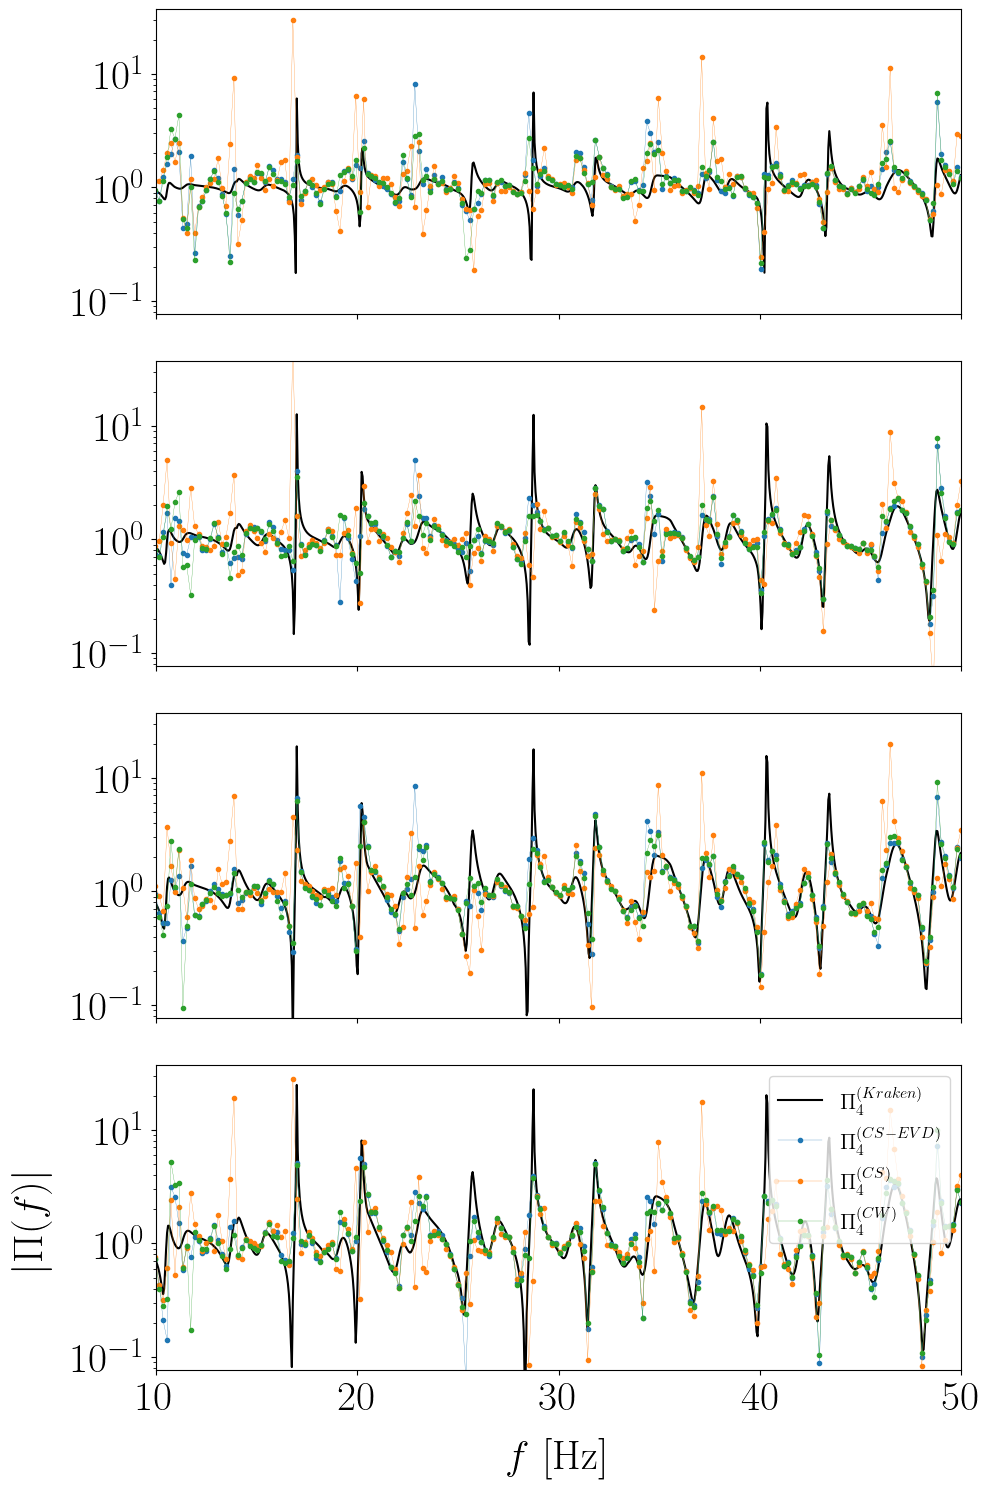

In [85]:
# lfig = LargeFigure()

# ircv = 4
ymax = 1.5 * np.max(np.abs(rtf_kraken).values)
ymin = 1.5 * np.min(np.abs(rtf_kraken).values)

# plt.figure()
fig, axs = plt.subplots(hla_nrcv-1, 1, sharex=True, figsize=(10, 15))
for ircv in range(1, hla_nrcv):
    ax = axs[ircv-1]
    np.abs(rtf_kraken).sel(idx_rcv=ircv).plot(
        x="f",
        label=r"$\Pi_{" + str(ircv) + r"}^{(Kraken)}$",
        linestyle="-",
        color="k",
        linewidth=1.5,
        ax=ax,
    )

    ax.plot(
        f,
        np.abs(rtf_cs_evd[:, ircv]),
        linestyle="-",
        label=r"$\Pi_{" + str(ircv) + r"}^{(" + "CS-EVD" + r")}$",
        # color="r",
        marker="o",
        linewidth=0.2,
        markersize=3,
    )
    ax.plot(
        f,
        np.abs(rtf_cs_fc[:, ircv]),
        linestyle="-",
        label=r"$\Pi_{" + str(ircv) + r"}^{(" + "CS" + r")}$",
        # color="r",
        marker="o",
        linewidth=0.2,
        markersize=3,
    )
    ax.plot(
        f,
        np.abs(rtf_cw[:, ircv]),
        linestyle="-",
        label=r"$\Pi_{" + str(ircv) + r"}^{(" + "CW" + r")}$",
        # color="r",
        marker="o",
        linewidth=0.2,
        markersize=3,
    )
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylim([ymin, ymax])
    ax.set_yscale("log")

plt.legend(fontsize=16)
plt.yscale("log")
plt.xlabel(r"$f$" + " [Hz]")
plt.ylabel(r"$|\Pi(f)|$")
plt.xlim([10, 50])
# plt.ylim([1e-1, 1e1])

On peut ainsi vérifier que les 3 estimateurs convergent vers la solution de référence. On peut également tester l'influence de la taille des fenêtres sur l'estimation : 

* Plus la taille des fenêtres augmentent plus l'estimation est résolue en fréquence (résolution = distance entre deux points) et les structures fines du vecteur de RTF peuvent être correctement caractérisées. 
* En contrepartie, lorsque la taille des snapshots augmente, le nombre de segments pour l'estimation de la matrice de covariance diminue et l'écart à la solution de le référence peut augmenter. 

-> Il y a donc un compromis à trouver 
